# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from typing import List, Union, Tuple

import sys
import os

import pickle

import comet_ml
import json


try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.estimate_scripts import get_mass_distributions
from analysis_scripts.draw_scripts import total_spectrum
from analysis_scripts.draw_scripts import tssa_area_plot
from analysis_scripts.draw_scripts import tssa_error_plot
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_const
from analysis_scripts.estimate_scripts import calculate_sb_ratio_2gauss_pol2
from analysis_scripts.estimate_scripts import calculate_tssa_sig_errors_local


CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Load Data

In [2]:
data_oc_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
data_mb_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df = data_oc_df.drop(['n_event'], axis=1)

mass_mask = (data_oc_df['true_decay'] == 1)
                
data_oc_df = data_oc_df[mass_mask]
data_oc_df['tag'] = 'Sig'

data_mb_df = data_mb_df.drop(['n_event'], axis=1)

data_mb_df['tag'] = 'Bg'

raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)

raw_df['cosAngle_r_Lc_momentum_Lc_xy'] = raw_df['cosAngle_r_Lc_momentum_Lc_xy'].apply(np.cos)
raw_df['cosAngle_r_Lc_sum_momentum_xy'] = raw_df['cosAngle_r_Lc_sum_momentum_xy'].apply(np.cos)
raw_df['cosAngle_momentum_Lc_sum_momentum_xy'] = raw_df['cosAngle_momentum_Lc_sum_momentum_xy'].apply(np.cos)


xf_and_pt_data = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/xF_annd_Pt_Lc_data_after_ML.csv')
xf_and_pt_data = xf_and_pt_data.drop(columns='Unnamed: 0', axis=1)

array([[<Axes: title={'center': 'xF'}>,
        <Axes: title={'center': 'Pt_Lc'}>]], dtype=object)

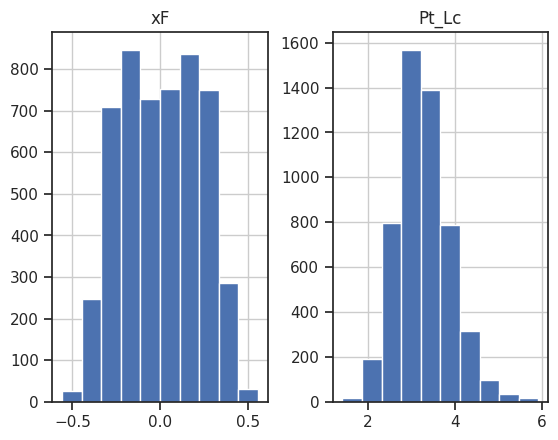

In [3]:
xf_and_pt_data.hist()

In [4]:
with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/preselection_mask_train_pickle.pkl", "rb") as f:
    preselection_mask = pickle.load(f)

proc_df = raw_df.query(preselection_mask).reset_index(drop=True)

proc_mass_min = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].min()
proc_mass_max = proc_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].max()

In [5]:
sig_mass_distr = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc']

# ML sel
sig_eff = 0.0538
bg_eff = 3.44e-5

total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773
)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Yield Mass Distribution'}, xlabel='Mass (GeV)', ylabel='Counts'>)

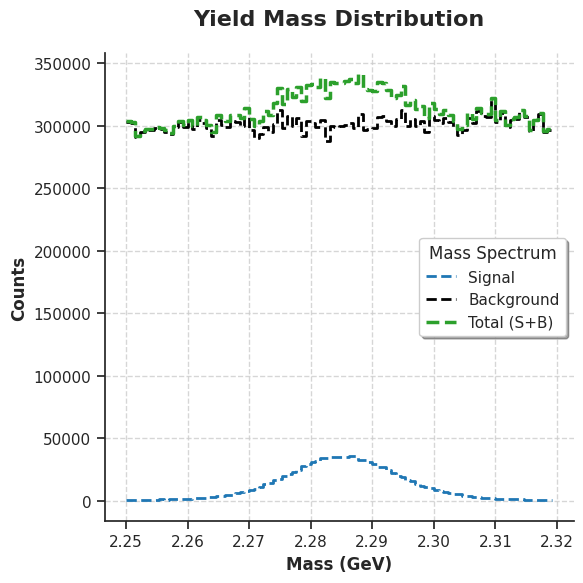

In [6]:
# xf_limits = [-0.3, 0.3]
# phi_limit = [0., np.pi / 6]
# 
# mask = (phi_limit[0] < proc_df['phi_angle']) & (proc_df['phi_angle'] < phi_limit[1])
# mask &= (xf_limits[0] < proc_df['xF']) & (proc_df['xF'] < xf_limits[1])
# 
# sig_mass_distr = proc_df.loc[(proc_df['tag'] == 'Sig') & mask, 'mass_Lc']
# bg_mass_distr = proc_df.loc[(proc_df['tag'] == 'Bg') & mask, 'mass_Lc']

sig_mass_distr = proc_df.loc[(proc_df['tag'] == 'Sig'), 'mass_Lc']
bg_mass_distr = proc_df.loc[(proc_df['tag'] == 'Bg'), 'mass_Lc']

total_spectrum(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1 / sig_eff, 
    have_bg_events=CFG.have_bg_events_1 / bg_eff,
    mass_interval=(2.25, 2.32),
    gev_per_bin=0.000773,
    log_y=False,
    only_total=False,
    line_style='--'
)

# TSSA areas plots (flat bkg, presel distributions)

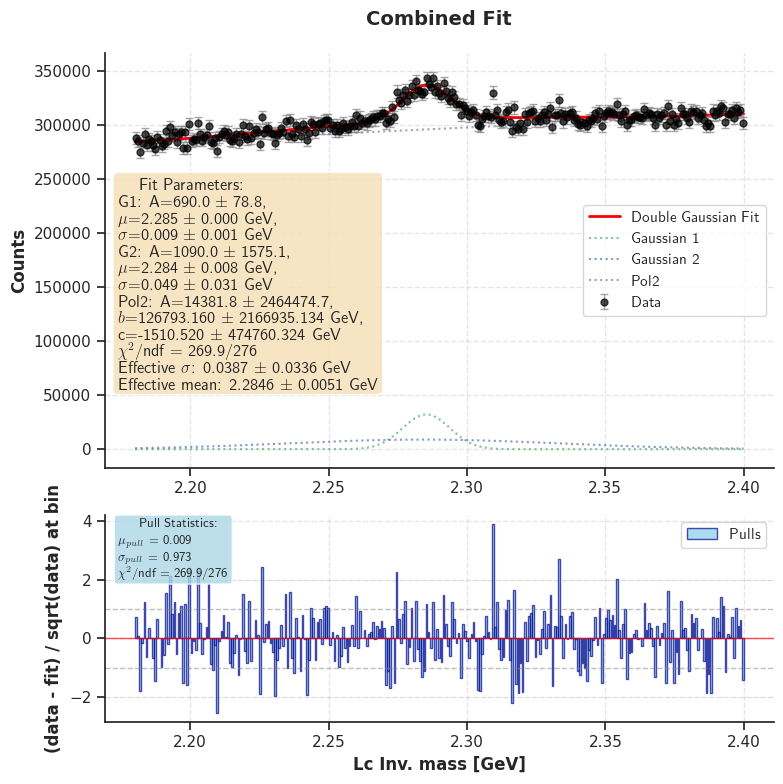

In [7]:
with open("/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/combined_fit_ML_wide_2gauss_pol2.pkl", "rb") as f:
    fit_result = pickle.load(f)

In [8]:
# mean = 2.2856

# min_raw = 2.18 (mean - 11.55 small sigma) (mean - 4.50 small sigma)
# max_raw = 2.4 (mean + 12.36 small sigma) (mean + 4.82 big sigma)

# sigma MC = 0.0092 (mass_interval(2.24763, 2.32497) = +-4.2 sigma)
# sigma CF = 0.023 (mass_interval(2.24763, 2.32497) = +-1.6 sigma)



# right peak = 2.301 (+-1.5 sigma small)
# left peak = 2.2725 

# right left bg = 2.3139 (3 sigma small)
# right right bg = 2.3231 (4 sigma small)

# left right bg = 2.2587 (3 sigma small)
# left left bg = 2.2495 (4 sigma small)



# right peak = 2.3201 (+-1.5 sigma big)
# left peak = 2.2511

# right left bg = 2.3546 (3 sigma big)
# right right bg = 2.3776 (4 sigma big) or max

# left right bg = 2.2166 (3 sigma big)
# left left bg = 2.1936 (4 sigma big) or min

/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/analysis_notebooks/supporting analysis/../../analysis_scripts/draw_scripts.py:675: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r:" (-> linestyle=':'). The keyword argument will take precedence.
  ax.plot(x_bins, g1 + g2 + pol2, 'r:', label=total_label, linestyle='-', linewidth=3, alpha=0.7)


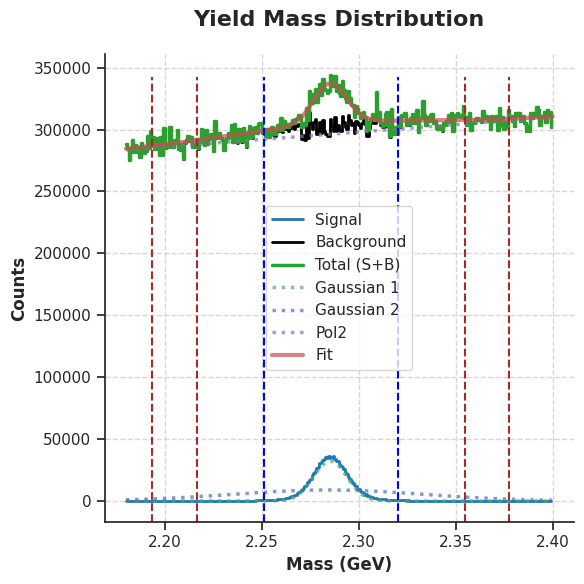

In [9]:
mean = 2.2856
sigma = 0.023

borders_pos = [
    mean - 4 * sigma,
    mean - 3 * sigma,
    mean - 1.5 * sigma,
    mean + 1.5 * sigma,
    mean + 3 * sigma,
    mean + 4 * sigma
]

tssa_area_plot(
    sig_mass_distr=sig_mass_distr, 
    bg_mass_distr=bg_mass_distr, 
    have_sig_events=CFG.have_sig_events_1,
    have_bg_events=CFG.have_bg_events_1,
    borders_pos=borders_pos,
    fit_params=fit_result[0]['params'],
    sig_eff=sig_eff,
    bg_eff=bg_eff,
    mass_interval=(proc_mass_min, proc_mass_max),
    gev_per_bin=0.000773,  # (2.32497 - 2.24763) / 100
    log_y=False,
    total=True,
    only_total=False,
    line_style='-'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/TSSA_areas_plot.pdf')

<Axes: >

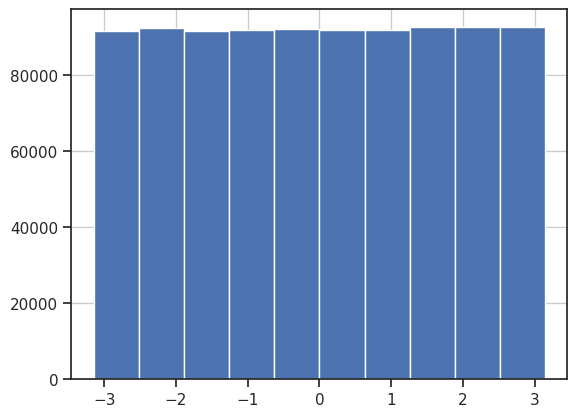

In [10]:
proc_df['phi_angle'].hist()

# TSSA Calculation

In [11]:
events_in_area = {
    'left': {'pos_1': borders_pos[0], 'pos_2': borders_pos[1], 'Sig': 0, 'Bg': 0, 'Sig_err': 0, 'Bg_err': 0},
    'peak': {'pos_1': borders_pos[2], 'pos_2': borders_pos[3], 'Sig': 0, 'Bg': 0, 'Sig_err': 0, 'Bg_err': 0},
    'right': {'pos_1': borders_pos[4], 'pos_2': borders_pos[5], 'Sig': 0, 'Bg': 0, 'Sig_err': 0, 'Bg_err': 0}
}

for area_pos in events_in_area.keys():
    
    stat_data = calculate_sb_ratio_2gauss_pol2(
        fit_result[0]['params'],
        bin_edges,
        cov_matrix=fit_result[0]['cov_matrix'],
        mass_interval=(events_in_area[area_pos]['pos_1'], events_in_area[area_pos]['pos_2'])
    )    
    
    events_in_area[area_pos]['Sig'] = stat_data['signal']
    events_in_area[area_pos]['Sig_err'] = stat_data['signal_uncertainty']
    events_in_area[area_pos]['Bg'] = stat_data['background']
    events_in_area[area_pos]['Bg_err'] = stat_data['background_uncertainty']


events_in_area

{'left': {'pos_1': 2.1936,
  'pos_2': 2.2166,
  'Sig': np.float64(56.24051503686927),
  'Bg': np.float64(6592.45542982372),
  'Sig_err': np.float64(141.20835655588593),
  'Bg_err': np.float64(141.16165850693352)},
 'peak': {'pos_1': 2.2511,
  'pos_2': 2.3201,
  'Sig': np.float64(1255.6327940313142),
  'Bg': np.float64(20443.924350953777),
  'Sig_err': np.float64(571.8543968683222),
  'Bg_err': np.float64(579.1786883363513)},
 'right': {'pos_1': 2.3546,
  'pos_2': 2.3776,
  'Sig': np.float64(51.12450976843793),
  'Bg': np.float64(7036.40170239954),
  'Sig_err': np.float64(123.34159869804432),
  'Bg_err': np.float64(122.42599377994132)}}

In [12]:
def get_part_of_events_in_range(
    feature_range: Union[List, Tuple],
    distr: pd.Series,
    is_abs: bool
):
    counts_all = distr.count()
    
    if is_abs:
        counts_in = distr[(feature_range[0] <= np.abs(distr)) & (np.abs(distr) <= feature_range[1])].count()
    else:
        counts_in = distr[(feature_range[0] <= distr) & (distr <= feature_range[1])].count()
    
    return counts_in / counts_all

In [13]:
phi_gaps = [(0., np.pi / 6), (np.pi / 6, np.pi * 2 / 6), (np.pi * 2 / 6, np.pi * 3 / 6), (np.pi * 3 / 6, np.pi * 4 / 6), (np.pi * 4 / 6, np.pi * 5 / 6), (np.pi * 5 / 6, np.pi)]
gaps = [(0., 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 1.)]
is_abs = True

tssa_errors_list = []

for gap in gaps:

    tssa_errors_in_phi_gaps = []
    
    for phi_gap in phi_gaps:
    
        distr_part = get_part_of_events_in_range(
            feature_range=gap,
            distr=xf_and_pt_data['xF'],
            is_abs=is_abs
        )

        #################################################
        # peak
                
        mask = (gap[0] <= np.abs(proc_df['xF'])) & (np.abs(proc_df['xF']) <= gap[1])

        sig_mass_distr = proc_df.loc[(proc_df['tag'] == 'Sig') & mask, 'mass_Lc']
        bg_mass_distr = proc_df.loc[(proc_df['tag'] == 'Bg') & mask, 'mass_Lc']
        
        total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
            sig_mass_distr=sig_mass_distr, 
            bg_mass_distr=bg_mass_distr, 
            have_sig_events=CFG.have_sig_events_1 / CFG.ML_sig_eff, 
            have_bg_events=CFG.have_bg_events_1 / CFG.ML_bg_eff,
            mass_interval=(borders_pos[2], borders_pos[3]),
            gev_per_bin=0.000773
        )
    
        # Count
        N_raw_phi = np.sum(total_heights) / 12 # 12 phi sectors
        N_raw_phi_pi = np.sum(total_heights) / 12

        # Count
        N_bg_peak_phi = np.sum(bg_heights) / 12
        N_bg_peak_phi_pi = np.sum(bg_heights) / 12
    
        # Fit
        # N_raw_phi = np.sum(total_heights) * distr_part/ 12
        # N_raw_phi_pi = np.sum(total_heights) * distr_part/ 12
    
        # Fit
        # N_bg_peak_phi = events_in_area['peak']['Bg'] * distr_part / 12
        # N_bg_peak_phi_pi = events_in_area['peak']['Bg'] * distr_part / 12
        
        #################################################
        # side
        
        # Count
        
        total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
            sig_mass_distr=sig_mass_distr, 
            bg_mass_distr=bg_mass_distr, 
            have_sig_events=CFG.have_sig_events_1 / CFG.ML_sig_eff, 
            have_bg_events=CFG.have_bg_events_1 / CFG.ML_bg_eff,
            mass_interval=(borders_pos[0], borders_pos[1]),
            gev_per_bin=0.000773
        )
        
        N_bg_side_phi = np.sum(bg_heights) / 12
        N_bg_side_phi_pi = np.sum(bg_heights) / 12
        
        total_heights, total_heights_errors, sig_heights, sig_heights_errors, bg_heights, bg_heights_errors, bin_edges, bin_centers = get_mass_distributions(
            sig_mass_distr=sig_mass_distr, 
            bg_mass_distr=bg_mass_distr, 
            have_sig_events=CFG.have_sig_events_1 / CFG.ML_sig_eff, 
            have_bg_events=CFG.have_bg_events_1 / CFG.ML_bg_eff,
            mass_interval=(borders_pos[4], borders_pos[5]),
            gev_per_bin=0.000773
        )
        
        N_bg_side_phi += np.sum(bg_heights) / 12
        N_bg_side_phi_pi += np.sum(bg_heights) / 12
        
        # Fit
        # N_bg_side_phi = events_in_area['left']['Bg'] * distr_part / 12 + events_in_area['right']['Bg'] * distr_part / 12
        # N_bg_side_phi_pi = events_in_area['left']['Bg'] * distr_part / 12 + events_in_area['right']['Bg'] * distr_part / 12
        
        print(f'{N_raw_phi=}')
        print(f'{N_raw_phi_pi=}')
        print(f'{N_bg_peak_phi=}')
        print(f'{N_bg_peak_phi_pi=}')
        print(f'{N_bg_side_phi=}')
        print(f'{N_bg_side_phi_pi=}')
        
        tssa_errors_in_phi_gaps.append(calculate_tssa_sig_errors_local(
            N_raw_phi=N_raw_phi,
            N_raw_phi_pi=N_raw_phi_pi,
            N_bg_peak_phi=N_bg_peak_phi,
            N_bg_peak_phi_pi=N_bg_peak_phi_pi,
            N_bg_side_phi=N_bg_side_phi,
            N_bg_side_phi_pi=N_bg_side_phi_pi,
            phi_1=phi_gap[0],
            phi_2=phi_gap[1],
        ))
        
        print(tssa_errors_in_phi_gaps)
        
    tssa_errors_in_phi_gaps = np.array(tssa_errors_in_phi_gaps)
    
    tssa_error = 1 / np.sqrt(np.sum(1 / tssa_errors_in_phi_gaps**2))
    
    tssa_errors_list.append(tssa_error)
                
                
tssa_errors_list = np.array(tssa_errors_list) 

N_raw_phi=np.float64(1100505.4906728698)
N_raw_phi_pi=np.float64(1100505.4906728698)
N_bg_peak_phi=np.float64(1055010.3740200917)
N_bg_peak_phi_pi=np.float64(1055010.3740200917)
N_bg_side_phi=np.float64(692598.715192212)
N_bg_side_phi_pi=np.float64(692598.715192212)
[np.float64(0.026781705464918672)]
N_raw_phi=np.float64(1100505.4906728698)
N_raw_phi_pi=np.float64(1100505.4906728698)
N_bg_peak_phi=np.float64(1055010.3740200917)
N_bg_peak_phi_pi=np.float64(1055010.3740200917)
N_bg_side_phi=np.float64(692598.715192212)
N_bg_side_phi_pi=np.float64(692598.715192212)
[np.float64(0.026781705464918672), np.float64(0.03658449002175144)]
N_raw_phi=np.float64(1100505.4906728698)
N_raw_phi_pi=np.float64(1100505.4906728698)
N_bg_peak_phi=np.float64(1055010.3740200917)
N_bg_peak_phi_pi=np.float64(1055010.3740200917)
N_bg_side_phi=np.float64(692598.715192212)
N_bg_side_phi_pi=np.float64(692598.715192212)
[np.float64(0.026781705464918672), np.float64(0.03658449002175144), np.float64(0.099950685508421

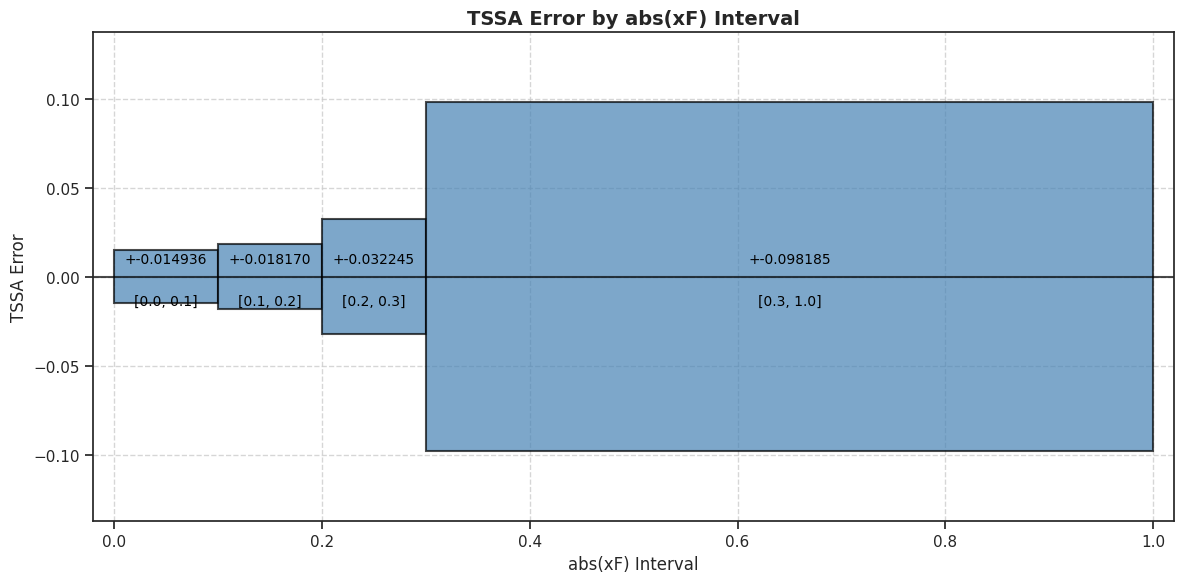

In [15]:
x_label = 'abs(xF)'

tssa_error_plot(
    gaps=gaps,
    tssa_errors_list=tssa_errors_list,
    x_label=x_label
)

plt.show()